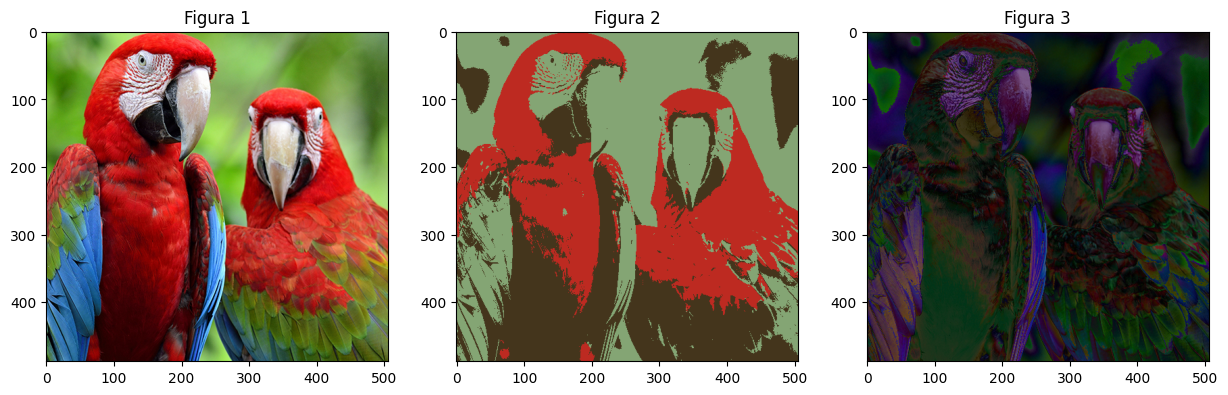

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.cluster import KMeans
from tqdm import tqdm
import os
def function_1(img, parameter):
    temp = np.reshape(img, (img.shape[0]*img.shape[1],3))
    model = KMeans(n_clusters=parameter, random_state=0, n_init=1).fit(temp)
    output = model.cluster_centers_[model.labels_]
    output = np.reshape(output,(img.shape[0],img.shape[1],3))
    return output
imagem = mpimg.imread('../data/araras.png')
output = function_1(imagem, 3)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
ax1.imshow(imagem)
ax1.set_title("Figura 1")
ax2.imshow(output)
ax2.set_title(f"Figura 2")
ax3.imshow(np.abs(imagem - output))
ax3.set_title("Figura 3")
plt.show()


A Figura 1 é a imagem original.A Figura 2 é a classificação de cada pixel em um dos três clusteres analisados. Cada cluster representa uma das três cores que melhor agrupavam as amostras em três grupos. A figura 3 é a parte da imagem que não foi incorporada na classificação anterior. Nela, foi retirado de cada pixel o clusterno qual ele foi classificado. 'parameter' representa o número de clusteres que serão considerados na decomposição da imagem. Quanto maior o número de clusteres, mais cores serão consideradas na classificação, e a imagem resultante da Figura 2 se aproximará mais da imagem original. Já a Figura 3 se aproximará de uma imagem completamente preta, pois cada vez menos pixels serão classificados como parte do cluster errado.
parameter = 3:



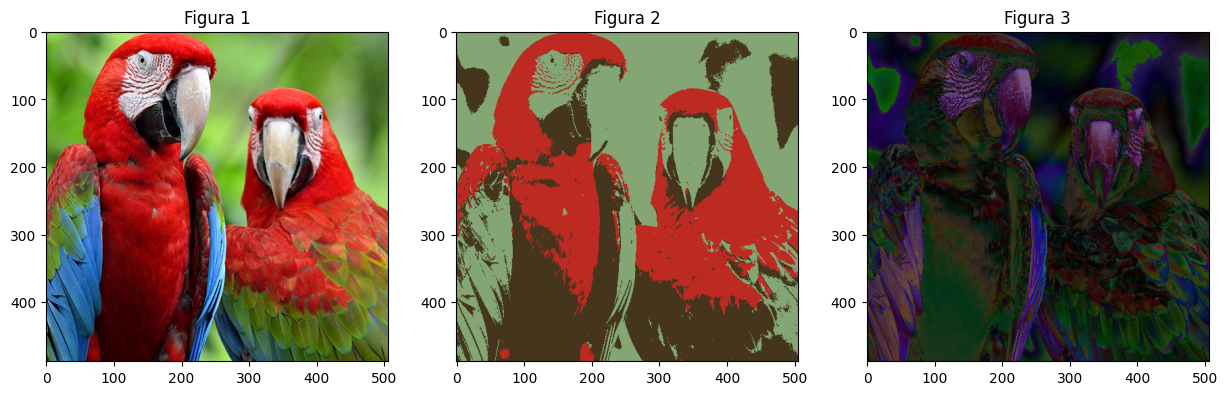

parameter = 10:



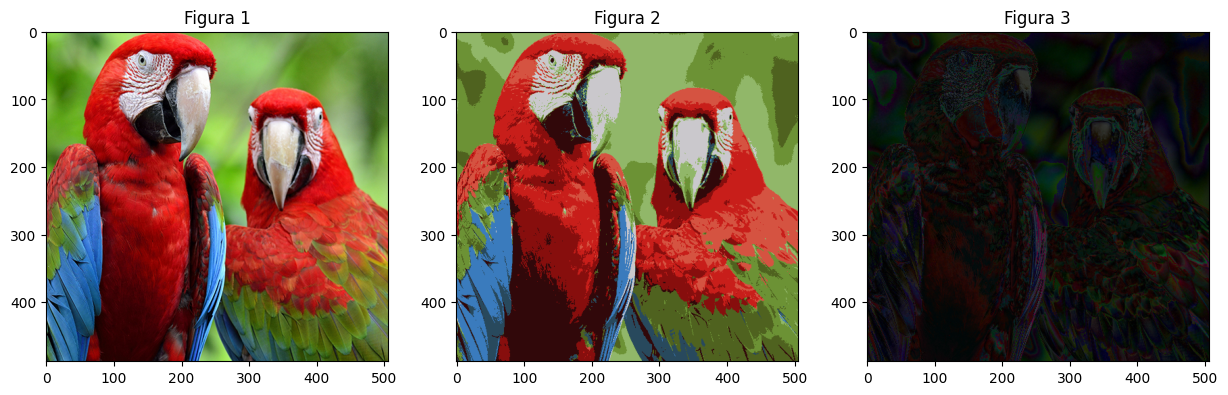

parameter = 30:



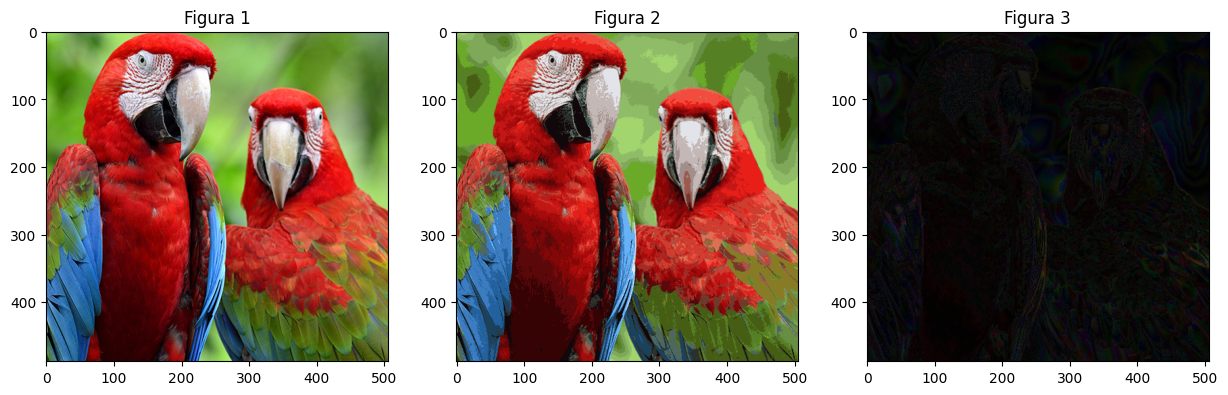

In [5]:
# a) Explique o que as Figuras 1, 2 e 3 representam no código acima e o impacto da variável parameter na Figura 2. Exiba o output do código acima para parameter=3, 10, 30.

print("A Figura 1 é a imagem original.A Figura 2 é a classificação de cada pixel em um dos três clusteres analisados. Cada cluster representa uma das três cores que " \
"melhor agrupavam as amostras em três grupos. A figura 3 é a parte da imagem que não foi incorporada na classificação anterior. Nela, foi retirado de cada pixel o cluster" \
"no qual ele foi classificado. 'parameter' representa o número de clusteres que serão considerados na decomposição da imagem. Quanto maior o número de clusteres, mais cores " \
"serão consideradas na classificação, e a imagem resultante da Figura 2 se aproximará mais da imagem original. Já a Figura 3 se aproximará de uma imagem completamente preta," \
" pois cada vez menos pixels serão classificados como parte do cluster errado.")

parameters = [3, 10, 30]
for parameter in parameters:
    output = function_1(imagem, parameter)
    print(f'parameter = {parameter}:\n')
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
    ax1.imshow(imagem)
    ax1.set_title("Figura 1")
    ax2.imshow(output)
    ax2.set_title(f"Figura 2")
    ax3.imshow(np.abs(imagem - output))
    ax3.set_title("Figura 3")
    plt.show()

In [ ]:
# (b) Em geral, um arquivo .png usa valores j/255, com j = 0, 1, . . . , 255 para a intensidade de cor (vermelho, verde ou azul) em cada pixel.
# Ou seja, cada intensidade é representada com no máximo log2 (256) = 8 bits por pixel e, portanto, cada pixel pode ser representado por até 
# 3 cores × 8 bits = 24 bits. Por outro lado, a function_1 retorna imagens comprimidas, isto é, em que o número de bits por pixel é potencialmente
# muito menor. Determine qual é o número de bits por pixel necessário em função de parameter

print('Considerando que cada classe terá a cor armazenada, precisamos apenas representar a classe na qual o pixel está inserido para reproduzir a imagem. Dessa forma, ' \
'o número de bits por pixel necessários será log2(parameter)') 

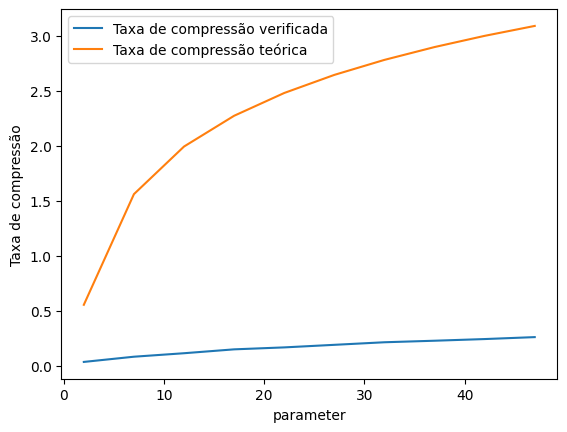

In [15]:
# (c) O código a seguir roda a função function_1 em um conjunto pré-definido de valores parameter e salva em uma lista a sua taxa de compressão,
# isto é, o tamanho em bits de cada output salvo dividido pelo tamanho em bits da imagem original. Faça um gráfico onde o eixo x é dado por 
# parameter_interval e o eixo y é dado pela taxa de compressão da imagem. Desenhe duas linhas, uma representando a taxa de compressão
# verificada na lista sizes e a outra representando a taxa de compressão teórica encontrada no item anterior. Comente o resultado.
os.makedirs('../results/', exist_ok=True)
parameter_interval = np.array(range(2, 50, 5))
for i in parameter_interval:
    image = mpimg.imread('../data/araras.png')
    tmp = function_1(image, i)
    plt.imsave(f"../results/imagem_{i}.png", tmp)

sizes = []
theoretical_sizes = []
original_size = os.path.getsize('../data/araras.png')

for i in parameter_interval:
    file_size = os.path.getsize(f'../results/imagem_{i}.png') 
    sizes.append(file_size / original_size)
    theoretical_sizes.append((np.log2(i) * image.shape[0] * image.shape[1] + i*3) / original_size)

plt.plot(parameter_interval, sizes, label='Taxa de compressão verificada')
plt.plot(parameter_interval, theoretical_sizes, label='Taxa de compressão teórica')
plt.xlabel('parameter')
plt.ylabel('Taxa de compressão')
plt.legend()
plt.show()